## 執行一次就好下載套件

In [1]:
!apt-get -y install fonts-noto-cjk




Suggested packages:
  fonts-noto-cjk-extra
The following NEW packages will be installed:
  fonts-noto-cjk
0 upgraded, 1 newly installed, 0 to remove and 165 not upgraded.
Need to get 61.2 MB of archives.
After this operation, 93.2 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-noto-cjk all 1:20220127+repack1-1 [61.2 MB]
Fetched 61.2 MB in 3s (18.6 MB/s)
Selecting previously unselected package fonts-noto-cjk.
(Reading database ... 128639 files and directories currently installed.)
Preparing to unpack .../fonts-noto-cjk_1%3a20220127+repack1-1_all.deb ...
Unpacking fonts-noto-cjk (1:20220127+repack1-1) ...
Setting up fonts-noto-cjk (1:20220127+repack1-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


## 下載資料集

In [2]:
import pandas as pd

train = pd.read_csv("/kaggle/input/playground-series-s5e10/train.csv")
test = pd.read_csv("/kaggle/input/playground-series-s5e10/test.csv")

train.shape, test.shape

((517754, 14), (172585, 13))

### 檢查資料集

In [3]:
print(train.head())

   id road_type  num_lanes  curvature  speed_limit  lighting weather  \
0   0     urban          2       0.06           35  daylight   rainy   
1   1     urban          4       0.99           35  daylight   clear   
2   2     rural          4       0.63           70       dim   clear   
3   3   highway          4       0.07           35       dim   rainy   
4   4     rural          1       0.58           60  daylight   foggy   

   road_signs_present  public_road time_of_day  holiday  school_season  \
0               False         True   afternoon    False           True   
1                True        False     evening     True           True   
2               False         True     morning     True          False   
3                True         True     morning    False          False   
4               False        False     evening     True          False   

   num_reported_accidents  accident_risk  
0                       1           0.13  
1                       0           

In [4]:
train.isna().sum()  

id                        0
road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
accident_risk             0
dtype: int64

## EDA :


### 按分類特徵繪製的平均事故風險長條圖


In [5]:
from matplotlib import font_manager, rcParams

font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"

# 先把字型註冊進 Matplotlib
font_manager.fontManager.addfont(font_path)

# 再用這個檔案建立 FontProperties
font_prop = font_manager.FontProperties(fname=font_path)
print("使用字型：", font_prop.get_name())

# 設定為預設字型
rcParams["font.family"] = font_prop.get_name()
rcParams["axes.unicode_minus"] = False

使用字型： Noto Sans CJK JP


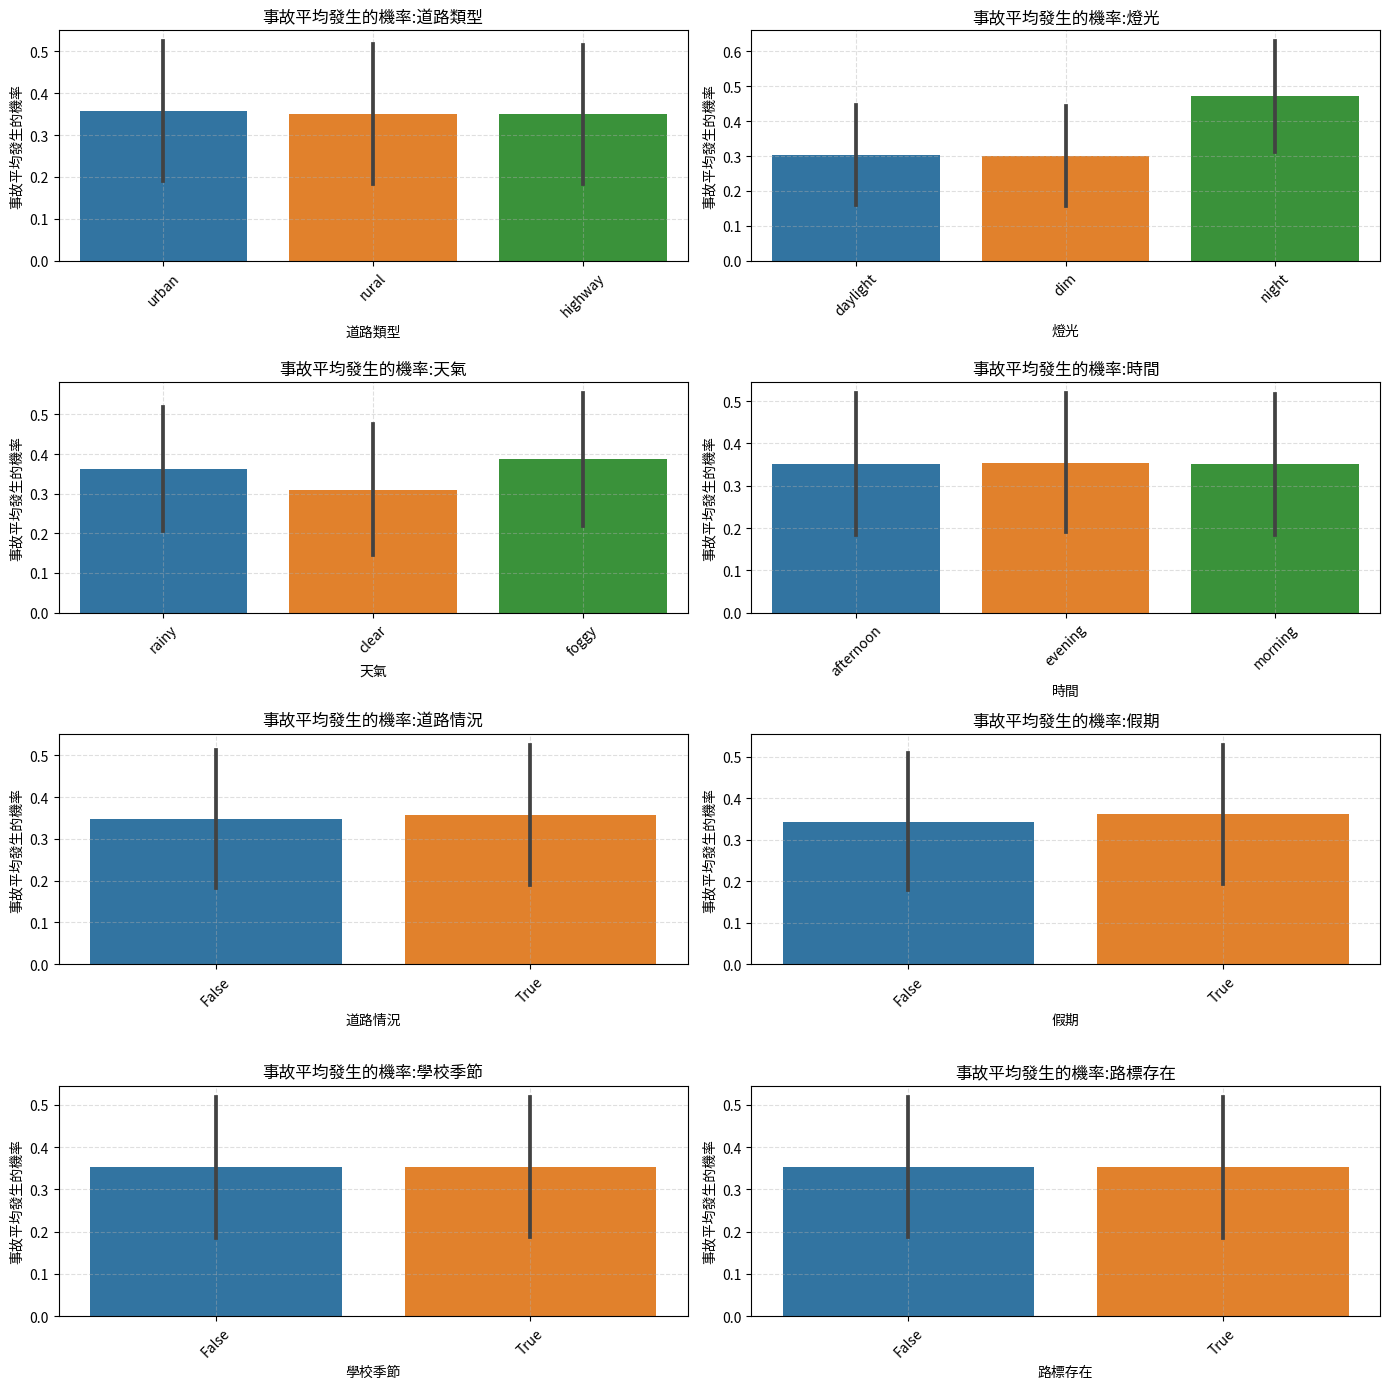

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
car_features = [
    'road_type', 'lighting', 'weather', 'time_of_day',
    'public_road', 'holiday', 'school_season', 'road_signs_present'
]
chinese_features = [
    '道路類型','燈光','天氣','時間','道路情況','假期','學校季節','路標存在'
]

fig, axes = plt.subplots(4, 2, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(car_features):
    sns.barplot(
        x=col,
        y='accident_risk',
        data=train,
        estimator='mean',
        errorbar='sd',
        ax=axes[i]
    )
    cname = chinese_features[i]
    
    axes[i].set_title(f"事故平均發生的機率:{cname}", fontsize=12, weight='bold')
    axes[i].set_xlabel(cname, fontsize=10)
    axes[i].set_ylabel("事故平均發生的機率", fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### 數值特徵分佈的直方圖


In [7]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

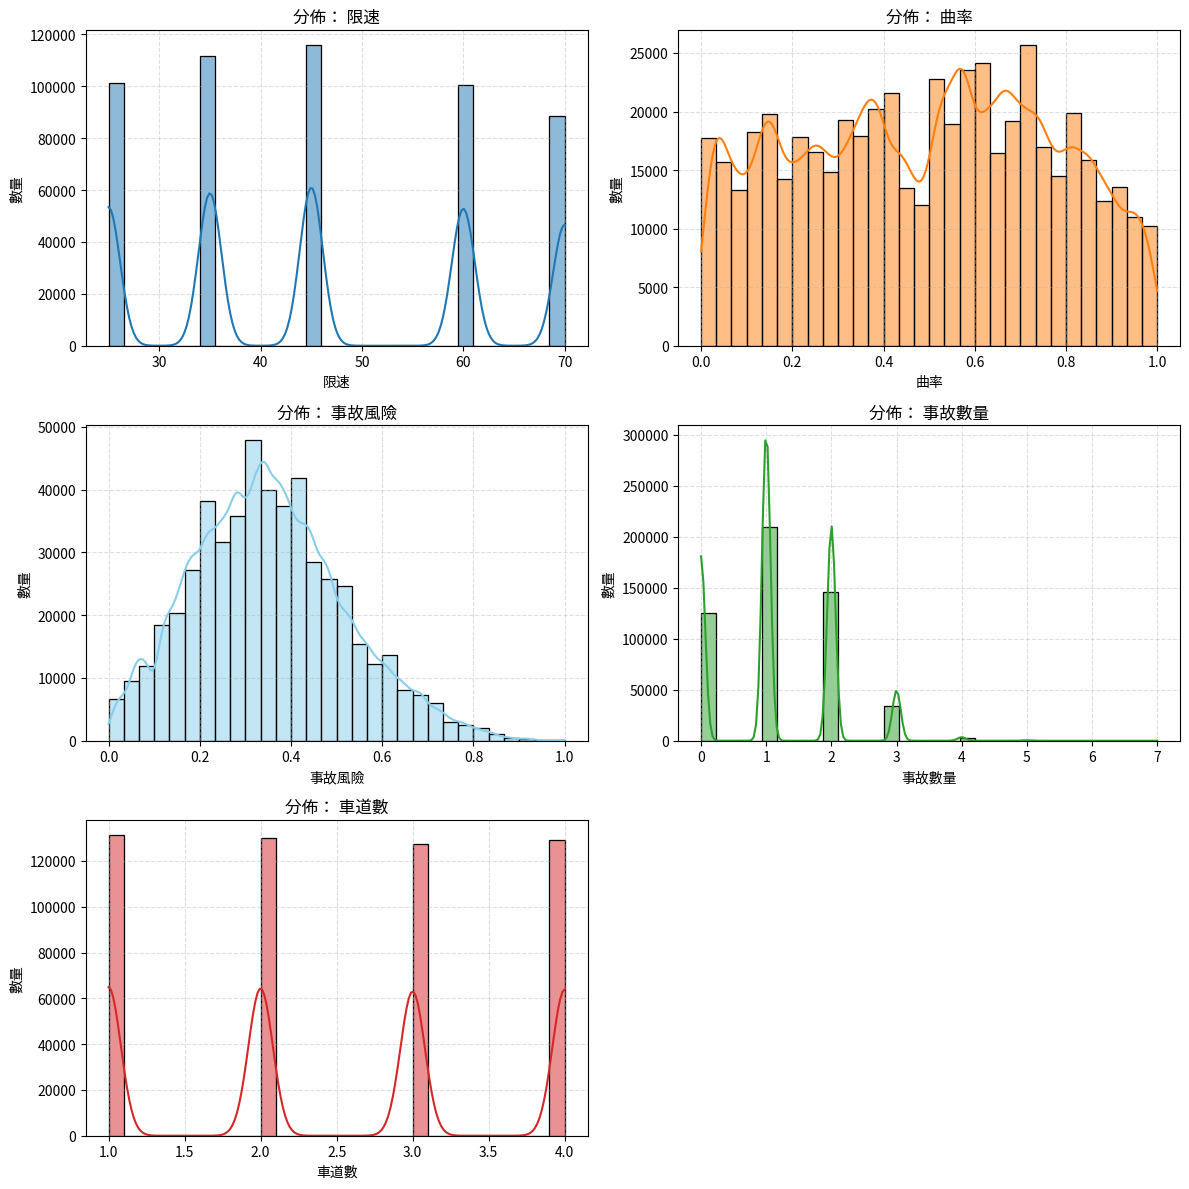

In [8]:
num_features = [
    'speed_limit', 'curvature', 'accident_risk',
    'num_reported_accidents', 'num_lanes'
]
chinese_features = [
    '限速','曲率','事故風險','事故數量','車道數'
]
colors = ['#1f77b4', '#ff7f0e', '#87ceeb', '#2ca02c', '#d62728']

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(train[col], bins=30, kde=True, color=colors[i], ax=axes[i])
    
    cname=chinese_features[i]
    
    axes[i].set_title(f"分佈： {cname}", fontsize=12)
    axes[i].set_xlabel(cname)
    axes[i].set_ylabel("數量")
    axes[i].grid(True, linestyle='--', alpha=0.4)

fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

### 離散和分箱連續特徵的事故風險箱線圖

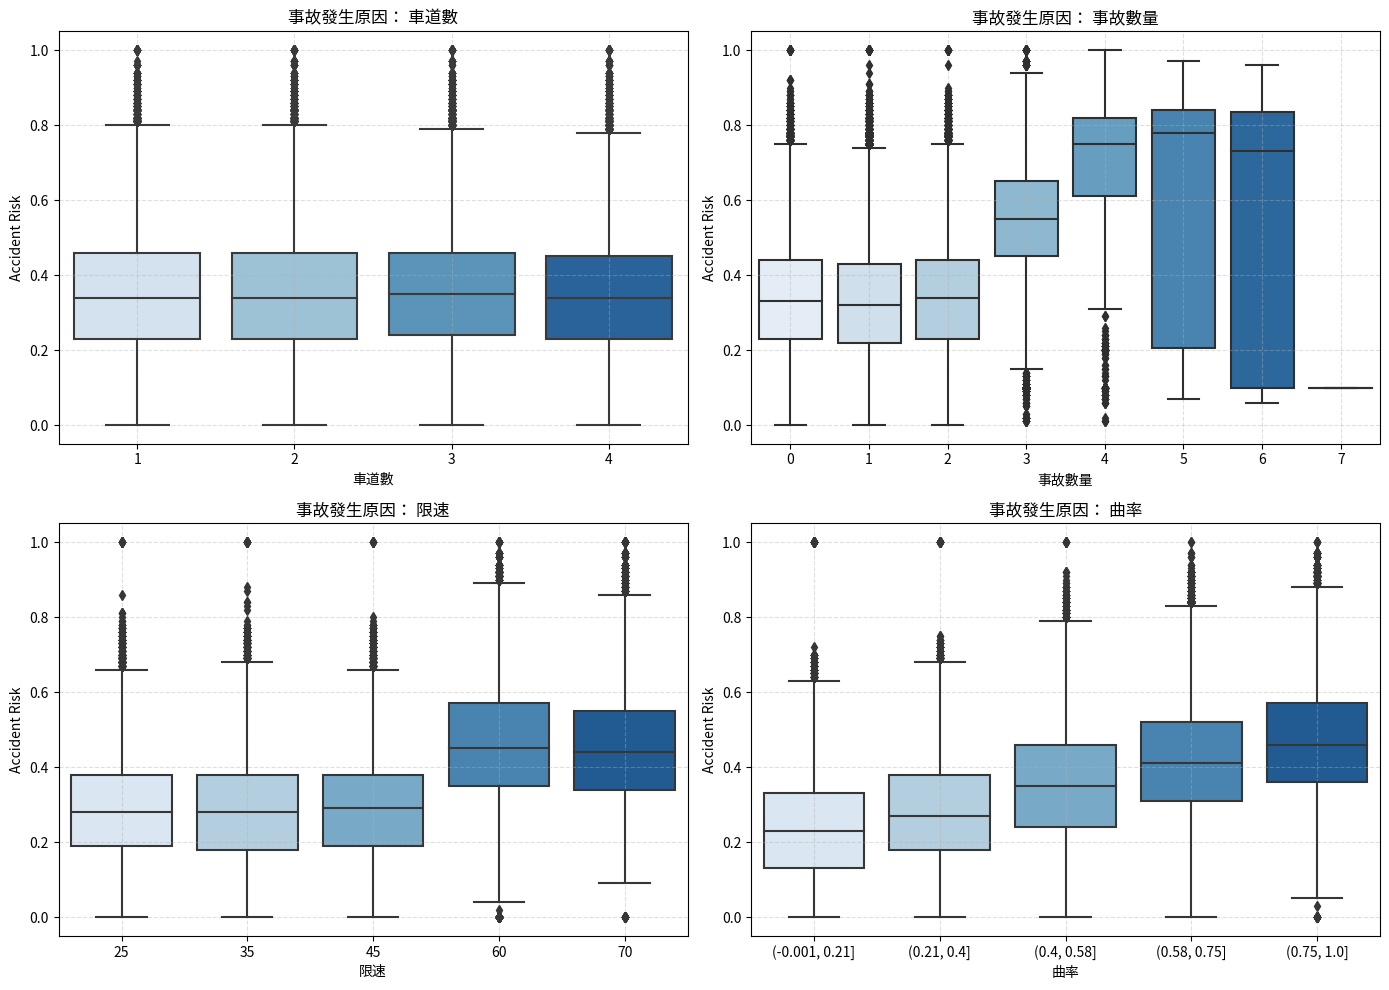

In [9]:
discrete_features = ['num_lanes', 'num_reported_accidents', 'speed_limit']
continuous_features = ['curvature']#連續值
all_features = discrete_features + continuous_features

chinese_features = [
    '車道數','事故數量','限速','曲率'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(all_features):
    if col in continuous_features:
        # Bin continuous feature into 5 quantiles
        train[f'{col}_bin'] = pd.qcut(train[col], q=5, duplicates='drop')
        x_col = f'{col}_bin'
    else:
        x_col = col  # Use discrete feature as is

    sns.boxplot(
        x=x_col,
        y='accident_risk',
        data=train,
        ax=axes[i],
        palette="Blues"
    )

    cname = chinese_features[i]
    axes[i].set_title(f"事故發生原因： {cname}", fontsize=12, weight='bold')
    axes[i].set_xlabel(cname, fontsize=10)
    axes[i].set_ylabel("Accident Risk", fontsize=10)
    axes[i].tick_params(axis='x')
    axes[i].grid(True, linestyle='--', alpha=0.4)

for j in range(len(all_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 預處理和特徵工程

**優化特徵權重以實現事故風險相關性最大化**

這樣 risk 變成一個向量（對每一筆資料都有一個算出的風險分數）。
    return -np.corrcoef(risk, df['accident_risk'])[0, 1]
np.corrcoef(risk, df['accident_risk'])[0, 1]：計算 risk 和真實事故風險 accident_risk 的皮爾森相關係數 ρ。
前面加負號 - → 因為 scipy.optimize.minimize 是「最小化」，所以你把「**最大化相關**」改寫成「**最小化負相關**」。
整個 neg_corr：
給我一組權重 → 我算出 risk → 算出 risk 和 accident_risk 的相關 → 回傳「負的相關係數」。

**這裡可能是可以微調的地方，之後可以嘗試****

In [10]:
import numpy as np
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error

def rmse_loss(weights, df):
    w_curv, w_light, w_weather, w_speed, w_acc = weights
    
    risk = (
        w_curv * df['curvature'] +
        w_light * (df['lighting'] == "night").astype(int) +
        w_weather * (df["weather"] != "clear").astype(int) +
        w_speed * (df['speed_limit'] >= 60).astype(int) +
        w_acc * (df['num_reported_accidents'] > 2).astype(int)
    )
    
    return mean_squared_error(df['accident_risk'], risk, squared=False)

# 權重範圍
bounds = [(0, 1)] * 5

# 初始值
np.random.seed(42)
random_start = np.random.rand(5)

# 最佳化
result = minimize(
    rmse_loss,
    random_start,
    args=(train,),
    bounds=bounds
)

best_weights = result.x

# 顯示結果
chinese_features = ['曲率','亮度','天氣','限速','事故數量']
print("最優係數（RMSE 最小）：")
for name, w in zip(chinese_features, best_weights):
    print(f"{name}: {w:.3f}")

final_rmse = rmse_loss(best_weights, train)
print(f"\n最終 RMSE: {final_rmse:.4f}")


最優係數（RMSE 最小）：
曲率: 0.314
亮度: 0.192
天氣: 0.098
限速: 0.189
事故數量: 0.095

最終 RMSE: 0.0582


**歸一化權重**

In [11]:
best_weights = np.array([0.314,0.192,0.098, 0.189, 0.095])
normalized_weights = np.round(best_weights / best_weights.sum(), 2)

for name, w in zip(chinese_features, normalized_weights):
    print(f"{name}: {w}")

曲率: 0.35
亮度: 0.22
天氣: 0.11
限速: 0.21
事故數量: 0.11


**基本風險特徵**

In [12]:
def compute_base_risk(df):
    return (
        0.35 * df["curvature"] +
        0.22 * (df["lighting"] == "night").astype(int) +
        0.11 * (df["weather"] != "clear").astype(int) +
        0.21 * (df["speed_limit"] >= 60).astype(int) +
        0.11 * (np.array(df["num_reported_accidents"]) > 2).astype(int)
    )

train["base_risk"] = compute_base_risk(train)
test["base_risk"] = compute_base_risk(test)

**特徵編碼（把文字轉成可以讀的編碼-onehot）**

In [13]:
categorical_cols = ['weather','road_type','time_of_day']
train = pd.get_dummies(train, columns=categorical_cols, drop_first=False)
test = pd.get_dummies(test, columns=categorical_cols, drop_first=False)

lighting_mapping = {'daylight': 0, 'dim': 0, 'night': 1}
train['lighting_encoded'] = train['lighting'].map(lighting_mapping)
test['lighting_encoded'] = test['lighting'].map(lighting_mapping)

binary_cols = ['holiday','school_season','road_signs_present','public_road']
for col in binary_cols:
    train[col] = train[col].astype(int)
    test[col] = test[col].astype(int)

**刪除 ID 列** 資料前處理的好習慣：識別欄位留下來做輸出映射，不讓模型學到毫無意義的「序號」。

In [14]:
test_ids = test['id']

train = train.drop(columns=['id'])
test = test.drop(columns=['id'])

**事故風險與工程特徵的箱型圖**

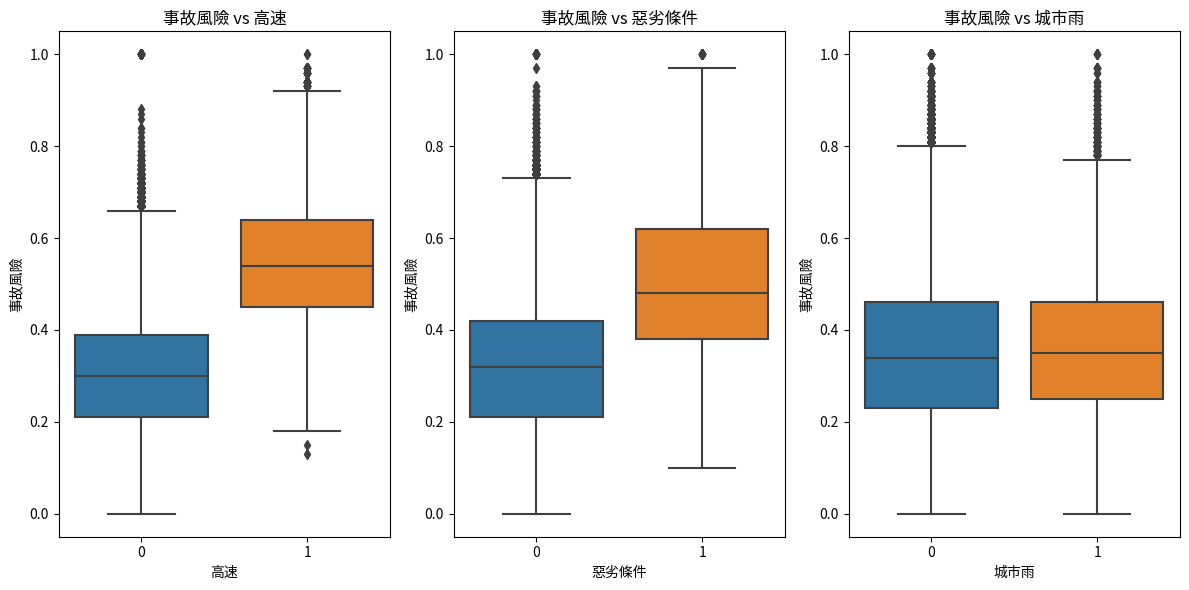

In [15]:
binary_features = {
    'High Speed Curve': (train['speed_limit'] >= 60) & (train['curvature'] > 0.5),
    'Bad Conditions': ((train.get('weather_rainy',0) == 1) | (train.get('weather_foggy',0) == 1)) & (train['lighting_encoded'] == 1),
    'Urban Rain': (train.filter(like='road_type_urban').max(axis=1) == 1) & (train.get('weather_rainy',0) == 1),
}

chinese_features = [
    '高速','惡劣條件','城市雨'
]

plt.figure(figsize=(12,6))

for i, (name, feature) in enumerate(binary_features.items(), 1):
    plt.subplot(1, 3, i)
    cname = chinese_features[i-1]
    sns.boxplot(x=feature.astype(int), y=train['accident_risk'])
    plt.title(f"事故風險 vs {cname}")
    plt.xlabel(cname)
    plt.ylabel("事故風險")

plt.tight_layout()
plt.show()

**事故風險與綜合特徵的散佈圖**

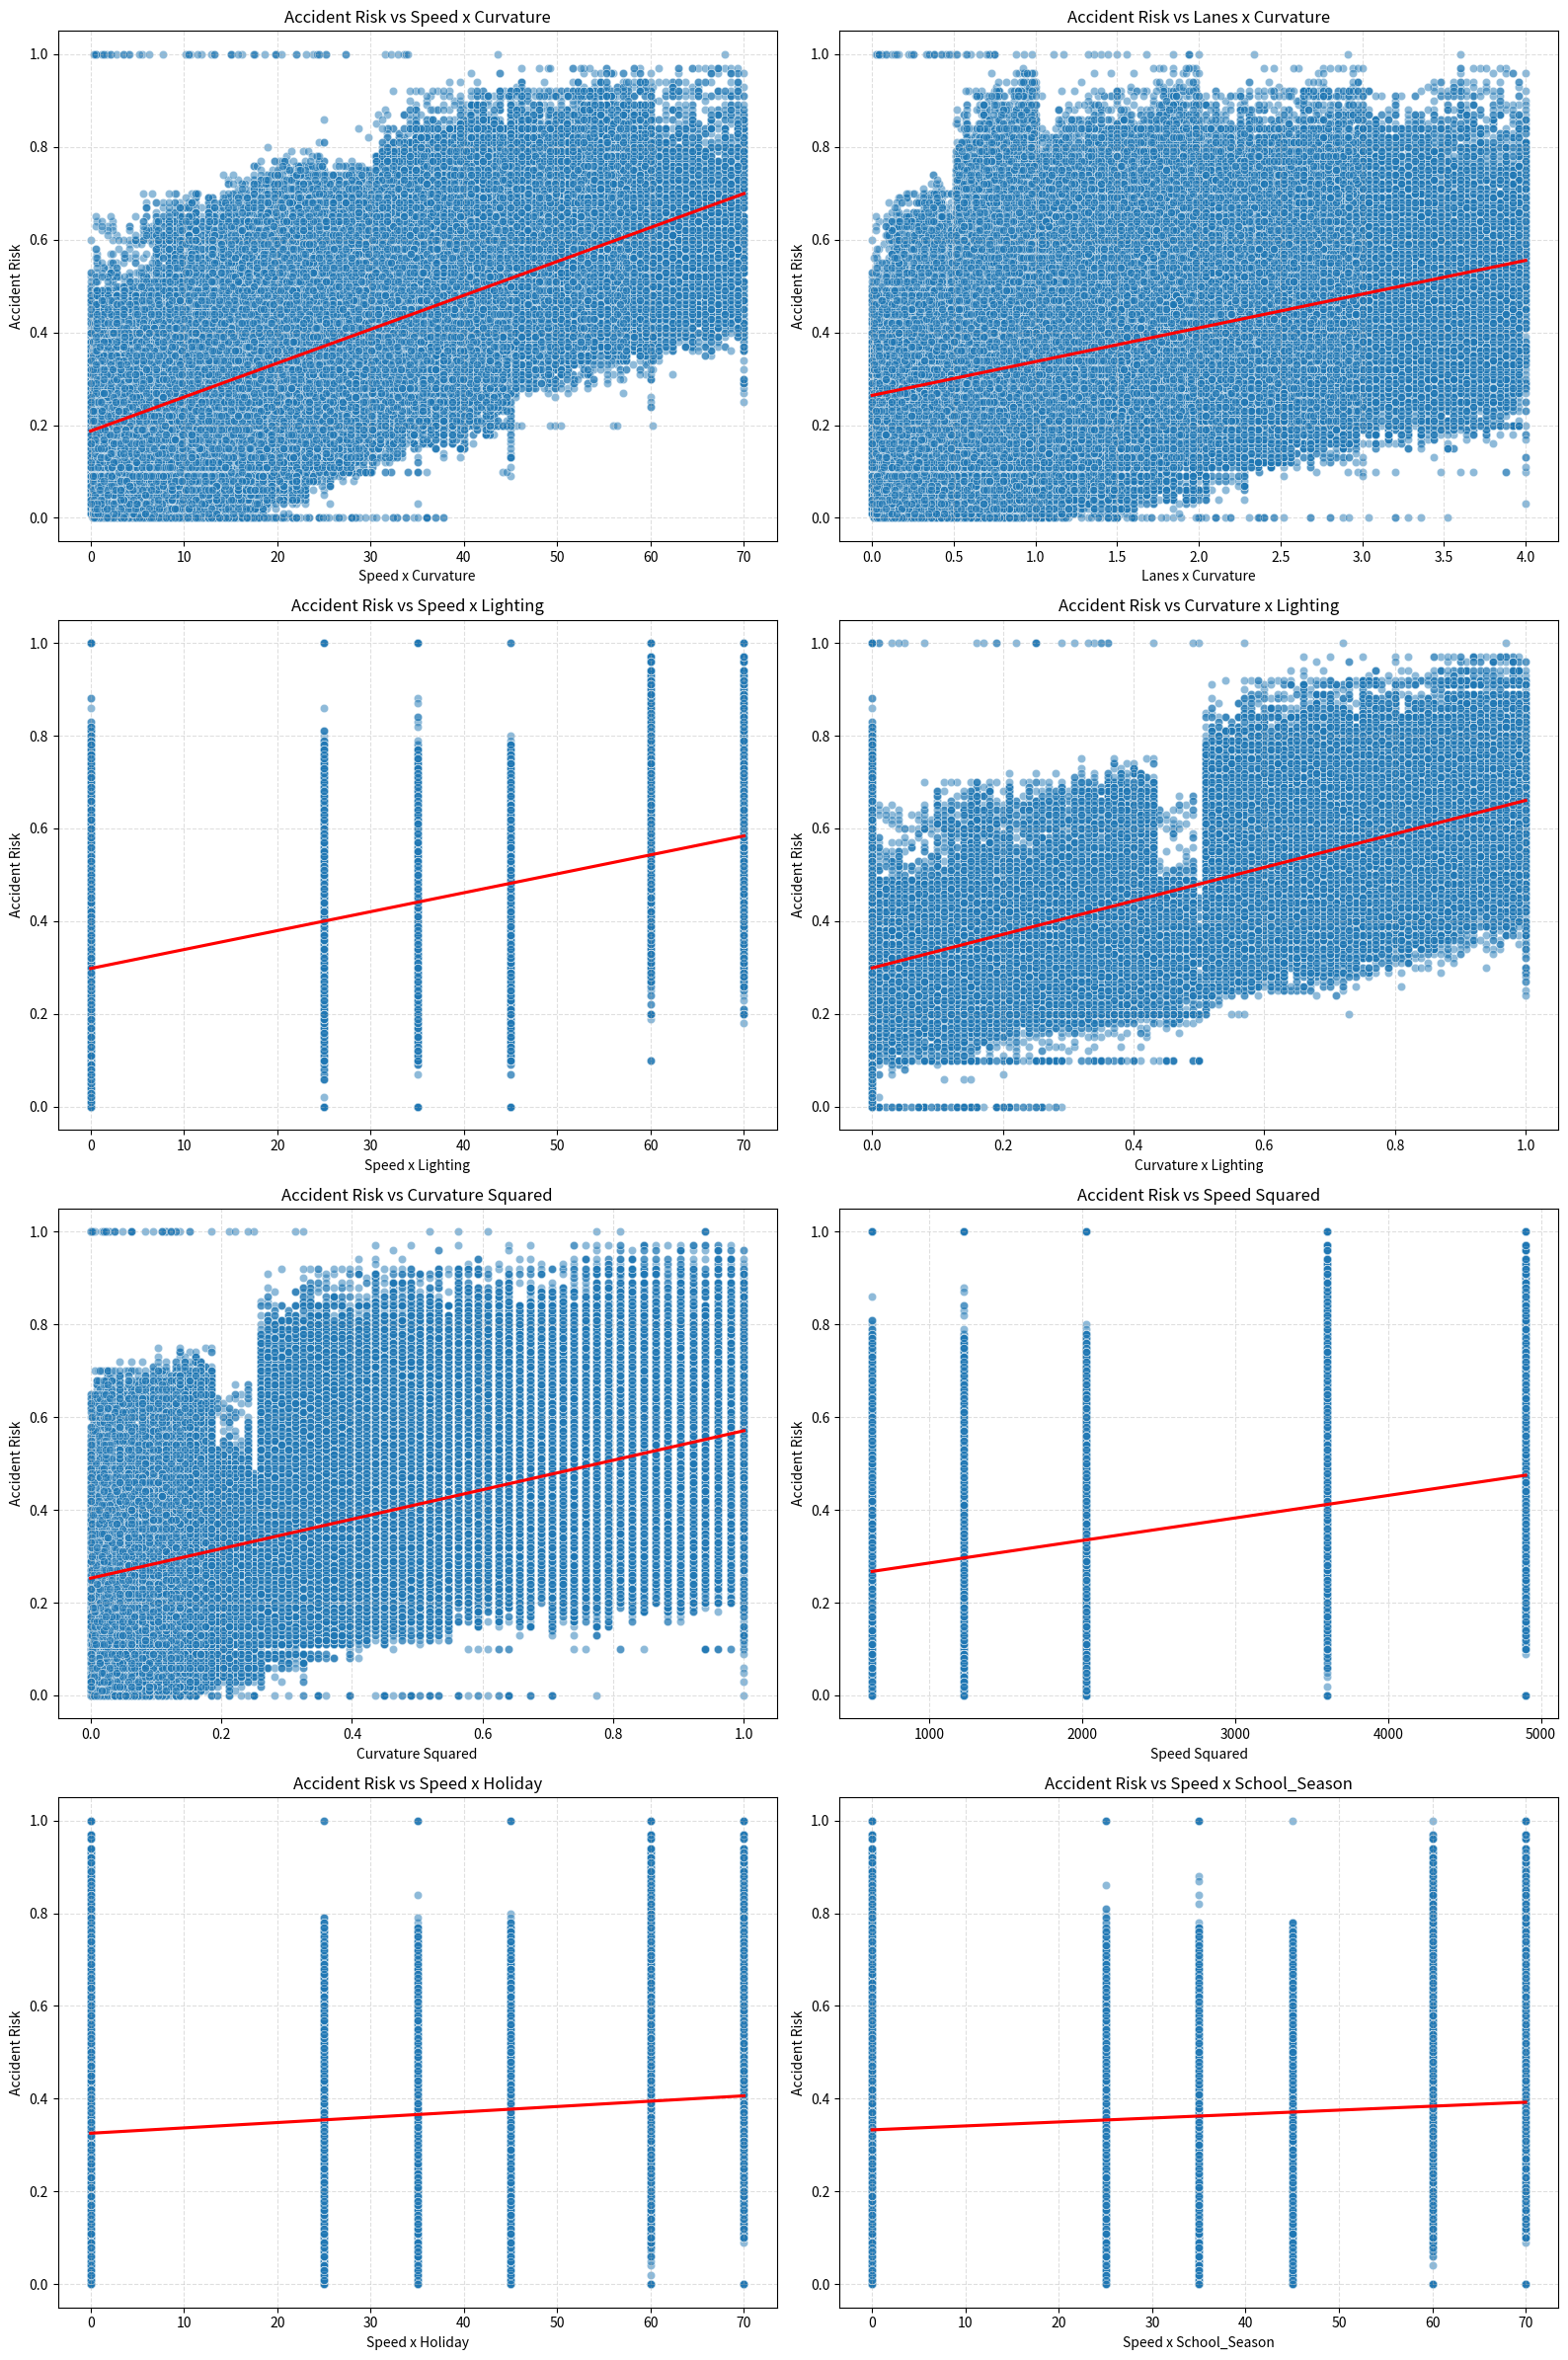

In [16]:
import math

combined_features = {
    'Speed x Curvature': train['speed_limit'] * train['curvature'],
    'Lanes x Curvature': train['num_lanes'] * train['curvature'],
    'Speed x Lighting': train['speed_limit'] * train['lighting_encoded'],
    'Curvature x Lighting': train['curvature'] * train['lighting_encoded'],
    'Curvature Squared': train['curvature'] ** 2,
    'Speed Squared': train['speed_limit'] ** 2,
    'Speed x Holiday': train['speed_limit'] * train['holiday'],
    'Speed x School_Season': train['speed_limit'] * train['school_season'],

}

features = combined_features
n_features = len(features)
n_cols = 2
n_rows = math.ceil(n_features / n_cols)

plt.figure(figsize=(16, 6*n_rows))

for i, (name, feature) in enumerate(features.items(), 1):
    plt.subplot(n_rows, n_cols, i)
    sns.scatterplot(x=feature, y=train['accident_risk'], alpha=0.5)
    sns.regplot(x=feature, y=train['accident_risk'], scatter=False, color='red')
    plt.title(f"Accident Risk vs {name}")
    plt.xlabel(name)
    plt.ylabel("Accident Risk")
    plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

**基於圖表分析創建互動和衍生功能**

In [17]:
for df in [train, test]:
    df['speed_curvature'] = df['speed_limit'] * df['curvature']
    df['lanes_curvature'] = df['num_lanes'] * df['curvature']
    df['speed_lighting'] = df['speed_limit'] * df['lighting_encoded']
    df['curvature_lighting'] = df['curvature'] * df['lighting_encoded']
    df['high_speed_curve'] = ((df['speed_limit'] >= 60) & (df['curvature'] > 0.5)).astype(int)
    df['curvature_squared'] = df['curvature'] ** 2
    df['speed_squared'] = df['speed_limit'] ** 2
    df['bad_conditions'] = (((df.get('weather_rainy',0) == 1) | (df.get('weather_foggy',0) == 1)) & (df['lighting_encoded'] == 1)).astype(int)
   
for col in train.columns:
    if col not in test.columns and col != 'accident_risk':
        test[col] = 0

**檢查並刪除重複項**

In [18]:
num_duplicates = train.duplicated().sum()
print("Number of duplicate rows:", num_duplicates)

Number of duplicate rows: 656


In [19]:
train = train.drop_duplicates()

## 模型建構


1. 在前面完成的前處理與特徵工程的基礎上，切出訓練集與驗證集。
2. 建立數個常見的迴歸模型（Linear Regression、Random Forest、Gradient Boosting）。
3. 以競賽指定指標 **RMSE（Root Mean Squared Error）** 為主、\(R^2\) 為輔，比較不同模型表現。
4. 對表現較好的樹模型進行簡單超參數調整（調參），再利用最佳參數訓練最終模型並產出預測結果。

In [20]:
target_col = "accident_risk"
X = train.drop(columns=[target_col])
y = train[target_col]

print(X.shape, y.shape)


(517098, 29) (517098,)


In [21]:
for col in X.columns:
    if str(X[col].dtype).startswith("interval"):
        X[col] = X[col].astype(str)

for col in test.columns:
    if str(test[col].dtype).startswith("interval"):
        test[col] = test[col].astype(str)


In [22]:
combined = pd.concat([X, test], axis=0)

combined_encoded = pd.get_dummies(combined, drop_first=True)

X_encoded = combined_encoded.iloc[:len(X), :]
test_encoded = combined_encoded.iloc[len(X):, :]



In [23]:
def clean_cols(df):
    df = df.copy()
    new_cols = []
    for c in df.columns:
        col = str(c)
        col = col.replace('[', '')   # 移掉 [
        col = col.replace(']', '')   # 移掉 ]
        col = col.replace('<', 'lt_')  # 把 < 換成 lt_
        new_cols.append(col)
    df.columns = new_cols
    return df

# 對所有要拿去訓練 / 預測的資料做一次
X_encoded = clean_cols(X_encoded)
test_encoded = clean_cols(test_encoded)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, "Val:", X_val.shape)


Train: (413678, 34) Val: (103420, 34)


In [25]:
def evaluate_model(name, model, X_train, y_train, X_val, y_val, results_list):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    rmse = mean_squared_error(y_val, y_pred, squared=False)
    r2 = r2_score(y_val, y_pred)

    print(f"{name} -> RMSE: {rmse:.5f}, R^2: {r2:.4f}")

    results_list.append({
        "model": name,
        "rmse": rmse,
        "r2": r2
    })

    return model


## 不同模型比較

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score


results = []

In [27]:
# Linear Regression
lin_reg = LinearRegression()
lin_reg = evaluate_model("Linear Regression", lin_reg, X_train, y_train, X_val, y_val, results)

Linear Regression -> RMSE: 0.05790, R^2: 0.8789


In [28]:
# Random Forest(baseline Random Forest)
rf = RandomForestRegressor(
    n_estimators=10,
    max_depth=5,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

rf = evaluate_model("Random Forest", rf, 
                    X_train, y_train, X_val, y_val, results)


Random Forest -> RMSE: 0.05787, R^2: 0.8791


In [29]:
# XGB


gbr = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

gbr = evaluate_model("XGBoost (Better GB)", gbr, X_train, y_train, X_val, y_val, results)



XGBoost (Better GB) -> RMSE: 0.05594, R^2: 0.8870


In [30]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

#原本參數是抓下面註解那幾個，因為跑太慢所以我就先調小
param_distributions = {
    "n_estimators": [200, 300, 400],     # [200, 300, 400]
    "max_depth": [10, 15, 20],          #max_depth=[10, 15, 20]
    "min_samples_split": [2, 5, 10],   # 2, 5, 10
    "min_samples_leaf": [1, 2, 4] ,    # 1, 2, 4
    "max_features": ["sqrt", "log2"] #每棵樹更輕、記憶體用量更少、速度更快
}

base_rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf_search = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=param_distributions,
    n_iter=20,           # n_iter=20
    cv=5,                # cv=5
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=1,
    verbose=1
)

rf_search.fit(X_train, y_train)

print("Best params:", rf_search.best_params_)
print("Best CV RMSE:", -rf_search.best_score_)



Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 15}
Best CV RMSE: 0.056310408232795636


In [31]:
# Random Forest的自動調參
best_rf = rf_search.best_estimator_


y_val_pred = best_rf.predict(X_val)
val_rmse = mean_squared_error(y_val, y_val_pred, squared=False)
val_r2 = r2_score(y_val, y_val_pred)

print(f"Best Random Forest -> RMSE: {val_rmse:.5f}, R^2: {val_r2:.4f}")


Best Random Forest -> RMSE: 0.05615, R^2: 0.8862


In [32]:
# 重新載入原始 test
test_raw = pd.read_csv("/kaggle/input/playground-series-s5e10/test.csv")  # ←把路徑改成你的
test_ids = test_raw["id"].copy()

# 建立 test_encoded
test_encoded = pd.get_dummies(test_raw, drop_first=True)
X_encoded, test_encoded = X_encoded.align(test_encoded, join="left", axis=1)
test_encoded = test_encoded.fillna(0)


# 用三模型預測
lin_pred = lin_reg.predict(test_encoded)
rf_pred = best_rf.predict(test_encoded)
xgb_pred = gbr.predict(test_encoded)


# 生成提交檔
submission_linear = pd.DataFrame({"id": test_ids, "accident_risk": lin_pred})
submission_linear.to_csv("submission_linear.csv", index=False)

submission_rf = pd.DataFrame({"id": test_ids, "accident_risk": rf_pred})
submission_rf.to_csv("submission_rf.csv", index=False)

submission_xgb = pd.DataFrame({"id": test_ids, "accident_risk": xgb_pred})
submission_xgb.to_csv("submission_xgb.csv", index=False)

print("三模型 CSV 全部建立完成！")


三模型 CSV 全部建立完成！


**模明集成(xgb,rf,lr)**

In [33]:
weights = [0.35, 0.55, 0.10]  # xgb, rf, lr
ensemble_pred = (
    weights[0] * xgb_pred +
    weights[1] * rf_pred +
    weights[2] * lin_pred
)

submission = pd.DataFrame({
    "id": test_ids,
    "accident_risk": ensemble_pred
})
submission.to_csv("submission_ensemble_weighted.csv", index=False)

print("Weighted Ensemble submission saved!")


Weighted Ensemble submission saved!


In [34]:
from sklearn.linear_model import Ridge

# ========== 第一層：模型預測當特徵 ==========
stack_train = pd.DataFrame({
    "lin": lin_reg.predict(X_val),
    "rf": best_rf.predict(X_val),
    "xgb": gbr.predict(X_val)
})

stack_test = pd.DataFrame({
    "lin": lin_reg.predict(test_encoded),
    "rf": best_rf.predict(test_encoded),
    "xgb": gbr.predict(test_encoded)
})

# ========== 第二層 Meta Model ==========
meta_model = Ridge(alpha=1.0)
meta_model.fit(stack_train, y_val)

stack_pred = meta_model.predict(stack_test)

# ========== 生成提交 ==========
submission_stack = pd.DataFrame({
    "id": test_ids,
    "accident_risk": stack_pred
})
submission_stack.to_csv("submission_stacking.csv", index=False)

print("Stacking ensemble submission saved! -> submission_stacking.csv")


Stacking ensemble submission saved! -> submission_stacking.csv


**catboost**

In [35]:
from catboost import CatBoostRegressor


X = X_encoded.copy()
y = train["accident_risk"]


X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ========== CatBoost 設定 ==========
cat_model = CatBoostRegressor(
    iterations=3000,          
    learning_rate=0.03,       
    depth=8,
    loss_function="RMSE",
    random_seed=42,
    eval_metric="RMSE",
    early_stopping_rounds=200, # 自動停止避免過擬合
    verbose=200               
)

# ========== 模型訓練 ==========
cat_model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    use_best_model=True        # 儲存最佳迭代點
)

from sklearn.metrics import mean_squared_error
val_pred = cat_model.predict(X_val)
rmse = mean_squared_error(y_val, val_pred, squared=False)
print(f"CatBoost RMSE: {rmse:.5f}")


0:	learn: 0.1621605	test: 0.1621634	best: 0.1621634 (0)	total: 99.2ms	remaining: 4m 57s
200:	learn: 0.0564869	test: 0.0563715	best: 0.0563715 (200)	total: 7.31s	remaining: 1m 41s
400:	learn: 0.0561577	test: 0.0561480	best: 0.0561480 (400)	total: 14.5s	remaining: 1m 33s
600:	learn: 0.0559369	test: 0.0560299	best: 0.0560299 (600)	total: 21.7s	remaining: 1m 26s
800:	learn: 0.0557623	test: 0.0559734	best: 0.0559734 (800)	total: 29s	remaining: 1m 19s
1000:	learn: 0.0556150	test: 0.0559365	best: 0.0559365 (1000)	total: 36.3s	remaining: 1m 12s
1200:	learn: 0.0554793	test: 0.0559168	best: 0.0559167 (1197)	total: 43.5s	remaining: 1m 5s
1400:	learn: 0.0553534	test: 0.0559031	best: 0.0559028 (1392)	total: 50.5s	remaining: 57.7s
1600:	learn: 0.0552302	test: 0.0558945	best: 0.0558943 (1569)	total: 57.7s	remaining: 50.4s
1800:	learn: 0.0551099	test: 0.0558930	best: 0.0558920 (1730)	total: 1m 4s	remaining: 43.2s
2000:	learn: 0.0549931	test: 0.0558916	best: 0.0558912 (1989)	total: 1m 11s	remaining: 35

In [36]:
# 保留原始 id
test_raw = pd.read_csv("/kaggle/input/playground-series-s5e10/test.csv")
test_ids = test_raw["id"].copy()

# 預測
cat_pred = cat_model.predict(test_encoded)

submission_cat = pd.DataFrame({
    "id": test_ids,
    "accident_risk": cat_pred
})
submission_cat.to_csv("submission_catboost.csv", index=False)

print("submission_catboost.csv saved!")


submission_catboost.csv saved!


**用catboost殘差補正隨機森林**

In [37]:
from catboost import CatBoostRegressor
import numpy as np

# 取得 RF 在 validation 的預測
rf_val_pred = best_rf.predict(X_val)

#  計算殘差（實際 - RF預測）
residual_val = y_val - rf_val_pred


# 訓練 CatBoost 來學習殘差
residual_model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.03,
    depth=6,
    loss_function='RMSE',
    random_state=42,
    verbose=200
)

residual_model.fit(X_val, residual_val)


# 最終預測：RF + CatBoost殘差補正
rf_test_pred = best_rf.predict(test_encoded)
residual_test_pred = residual_model.predict(test_encoded)

final_pred = rf_test_pred + residual_test_pred


# 輸出提交 CSV
submission_residual = pd.DataFrame({
    "id": test_ids,
    "accident_risk": final_pred
})

submission_residual.to_csv("submission_residual_boosting.csv", index=False)
print("Residual Boosting submission saved! -> submission_residual_boosting.csv")


0:	learn: 0.0561491	total: 10.8ms	remaining: 21.5s
200:	learn: 0.0558869	total: 1.59s	remaining: 14.2s
400:	learn: 0.0557043	total: 3.19s	remaining: 12.7s
600:	learn: 0.0555181	total: 4.71s	remaining: 11s
800:	learn: 0.0553523	total: 6.29s	remaining: 9.42s
1000:	learn: 0.0551895	total: 7.91s	remaining: 7.89s
1200:	learn: 0.0550329	total: 9.48s	remaining: 6.31s
1400:	learn: 0.0548802	total: 11.1s	remaining: 4.74s
1600:	learn: 0.0547400	total: 12.7s	remaining: 3.16s
1800:	learn: 0.0545991	total: 14.3s	remaining: 1.58s
1999:	learn: 0.0544685	total: 15.9s	remaining: 0us
Residual Boosting submission saved! -> submission_residual_boosting.csv


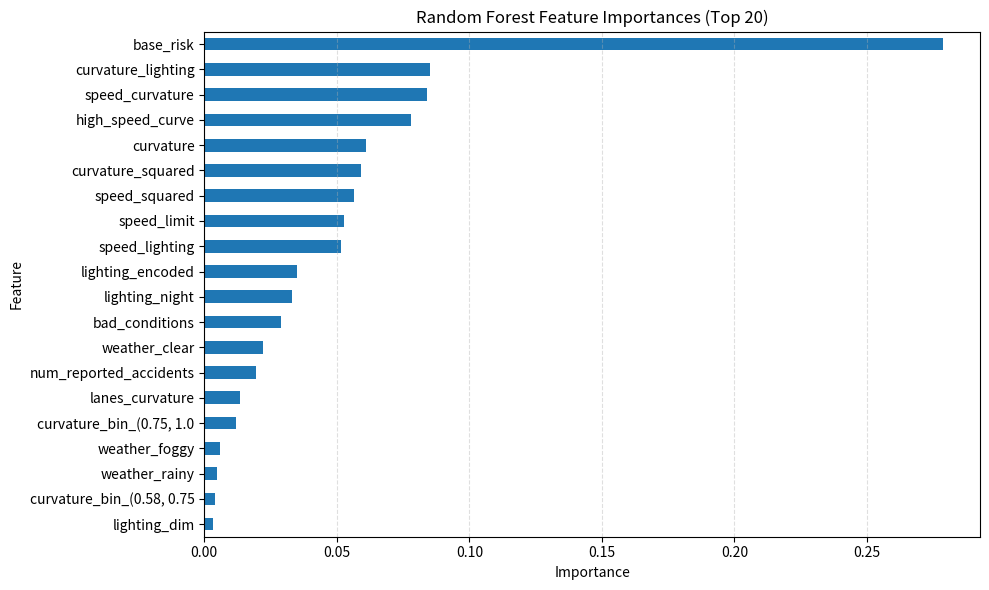

In [38]:
import matplotlib.pyplot as plt
import pandas as pd

#importances = pd.Series(best_rf.feature_importances_, index=X.columns)原版
importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
top_k = 20
top_importances = importances.sort_values(ascending=False).head(top_k)


plt.figure(figsize=(10, 6))
top_importances[::-1].plot(kind="barh")
plt.title("Random Forest Feature Importances (Top 20)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


In [39]:
# 用最佳模型跑一次


#final_model = best_rf
#final_model.fit(X_encoded, y)

#test_pred = final_model.predict(test_encoded)

#test_ids = test["id"]
#submission = pd.DataFrame({
#    "id": test_ids,
#    "accident_risk": test_pred
#})

#submission.head()


